
# LEI-Local Sensitivity (margin-based) — Análise de Interpretabilidade

Este notebook analisa as métricas geradas pelo script **LEI-Local Sensibilidade (margem de logit)**.

Ele espera encontrar, em um diretório `RUN_DIR`:

- `metrics_per_gen.csv`
- `config.json`
- `best_delta_z.npy`
- `final_population.pt` (opcional, para reconstrução de imagens)
- `best_final.png` (imagem do melhor contraexemplo encontrado)

Preencha a variável `RUN_DIR` na primeira célula.


In [25]:

# ======================
# 1. Imports e carregamento
# ======================
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

# >>>>> AJUSTE AQUI <<<<<
RUN_DIR = "outputs_lei_local_sensitivity/2025-12-10T23-47-00"

csv_path = os.path.join(RUN_DIR, "metrics_per_gen.csv")
config_path = os.path.join(RUN_DIR, "config.json")
delta_z_path = os.path.join(RUN_DIR, "best_delta_z.npy")
final_pop_path = os.path.join(RUN_DIR, "final_population.pt")
best_final_img_path = os.path.join(RUN_DIR, "best_final.png")

# Carrega CSV
df = pd.read_csv(csv_path)

# Carrega config
with open(config_path, "r") as f:
    config = json.load(f)

orig_class = config["ORIG_CLASS"]
orig_class_name = config["ORIG_CLASS_NAME"]
p0 = config["P0"]
trust_radius = config["TRUST_REGION_RADIUS"]

print("Classe original:", orig_class, orig_class_name)
print("p0:", p0)
print("Trust region radius (dist_norm):", trust_radius)
print("Linhas de métricas:", len(df))

# Carrega delta_z do melhor contraexemplo
best_delta_z = np.load(delta_z_path)

df.head()


Classe original: 3 cat
p0: 0.9858248233795166
Trust region radius (dist_norm): 1.0
Linhas de métricas: 87500


,generation,index,fitness,margin_logit,dist_norm,dist_raw,p_orig,p_other_max,pred_class,changed_class
0,1,0,-4.898862,-4.849147,0.099431,12.727168,0.981444,0.007690,3,0
1,1,1,-5.047673,-4.997425,0.100496,12.863482,0.982602,0.006638,3,0
2,1,2,-5.041366,-4.990492,0.101747,13.023570,0.981868,0.006679,3,0
3,1,3,-4.838709,-4.788485,0.100448,12.857400,0.980590,0.008163,3,0
4,1,4,-5.099478,-5.050086,0.098785,12.644444,0.982585,0.006297,3,0


## 2. Visão geral das métricas

In [26]:
df.describe()

,generation,index,fitness,margin_logit,dist_norm,dist_raw,p_orig,p_other_max,pred_class,changed_class
count,87500.000000,87500.000000,87500.000000,87500.000000,87500.000000,87500.000000,87500.000000,87500.000000,87500.000000,87500.000000
mean,175.500000,124.500000,6.351139,6.608449,0.514619,65.871280,0.036473,0.954495,4.926057,0.963029
std,101.036462,72.168619,2.076486,2.109722,0.071042,9.093382,0.172583,0.174211,0.377385,0.188693
min,1.000000,0.000000,-5.411898,-5.362409,0.075521,9.666680,0.000541,0.004619,3.000000,0.000000
25%,88.000000,62.000000,6.577916,6.837278,0.517258,66.209002,0.000602,0.989627,5.000000,1.000000
50%,175.500000,124.500000,6.905166,7.173132,0.540377,69.168270,0.000760,0.990611,5.000000,1.000000
75%,263.000000,187.000000,7.130530,7.405932,0.550419,70.453644,0.001064,0.991283,5.000000,1.000000
max,350.000000,249.000000,7.234251,7.510601,0.604851,77.420876,0.985480,0.992006,5.000000,1.000000


In [27]:

num_gens = df["generation"].nunique()
num_inds = df["index"].nunique()
print("Número de gerações:", num_gens)
print("Número de indivíduos por geração (esperado):", num_inds)


Número de gerações: 350
Número de indivíduos por geração (esperado): 250


## 3. Evolução da margem, distância e taxa de mudança de classe

In [28]:

gen_stats = df.groupby("generation").agg({
    "margin_logit": ["mean", "max"],
    "dist_norm": "mean",
    "changed_class": "mean",
    "fitness": "max"
})
gen_stats.columns = ["margin_mean", "margin_max", "dist_norm_mean", "frac_changed", "fitness_max"]
gen_stats.head()


,margin_mean,margin_max,dist_norm_mean,frac_changed,fitness_max
generation,,,,,
1,-5.037962,-4.568061,0.100005,0.0,-4.618632
2,-4.908095,-4.149741,0.125578,0.0,-4.233962
3,-4.719622,-3.616889,0.155995,0.0,-3.710324
4,-4.503955,-3.065549,0.179156,0.0,-3.169399
5,-4.255296,-2.563805,0.198940,0.0,-2.684528


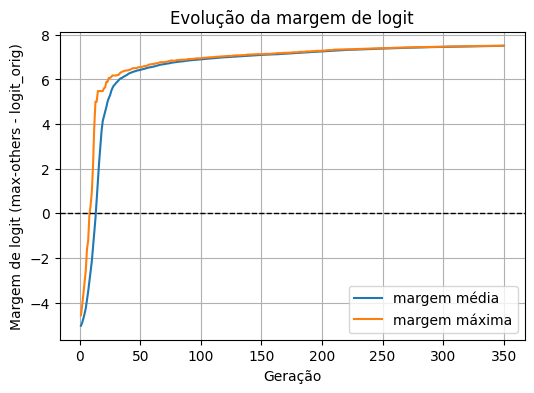

In [29]:

fig, ax = plt.subplots()
ax.plot(gen_stats.index, gen_stats["margin_mean"], label="margem média")
ax.plot(gen_stats.index, gen_stats["margin_max"], label="margem máxima")
ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Geração")
ax.set_ylabel("Margem de logit (max-others - logit_orig)")
ax.set_title("Evolução da margem de logit")
ax.legend()
plt.show()


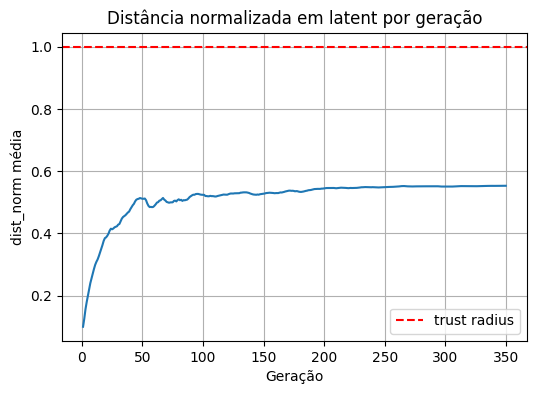

In [30]:

fig, ax = plt.subplots()
ax.plot(gen_stats.index, gen_stats["dist_norm_mean"])
ax.axhline(trust_radius, color="red", linestyle="--", label="trust radius")
ax.set_xlabel("Geração")
ax.set_ylabel("dist_norm média")
ax.set_title("Distância normalizada em latent por geração")
ax.legend()
plt.show()


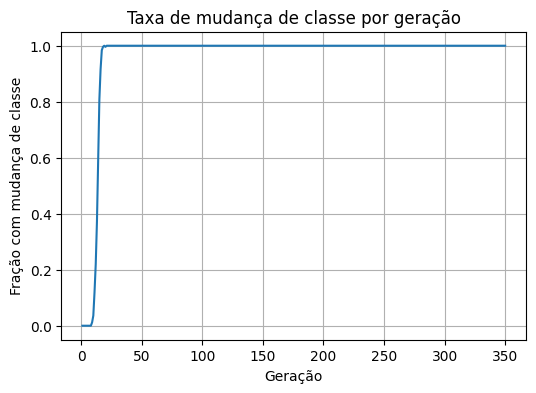

In [31]:

fig, ax = plt.subplots()
ax.plot(gen_stats.index, gen_stats["frac_changed"])
ax.set_xlabel("Geração")
ax.set_ylabel("Fração com mudança de classe")
ax.set_title("Taxa de mudança de classe por geração")
plt.show()


## 4. Trade-off local: margem vs distância

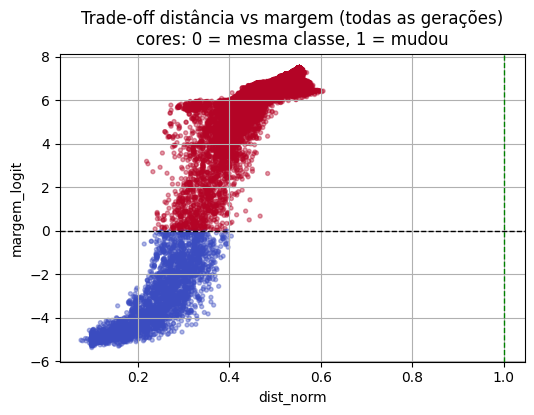

In [32]:
fig, ax = plt.subplots()
sc = ax.scatter(df["dist_norm"], df["margin_logit"],
                c=df["changed_class"], cmap="coolwarm", s=8, alpha=0.4)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax.axvline(trust_radius, color="green", linestyle="--", linewidth=1)
ax.set_xlabel("dist_norm")
ax.set_ylabel("margem_logit")
ax.set_title("Trade-off distância vs margem (todas as gerações)\n"
             "cores: 0 = mesma classe, 1 = mudou")
plt.show()


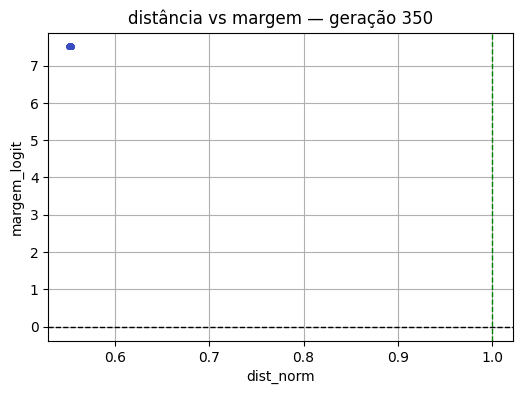

In [33]:

last_gen = df["generation"].max()
df_last = df[df["generation"] == last_gen]

fig, ax = plt.subplots()
ax.scatter(df_last["dist_norm"], df_last["margin_logit"],
           c=df_last["changed_class"], cmap="coolwarm", s=12, alpha=0.7)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax.axvline(trust_radius, color="green", linestyle="--", linewidth=1)
ax.set_xlabel("dist_norm")
ax.set_ylabel("margem_logit")
ax.set_title(f"distância vs margem — geração {last_gen}")
plt.show()


## 5. Distribuição de probabilidades (classe original vs melhor concorrente)

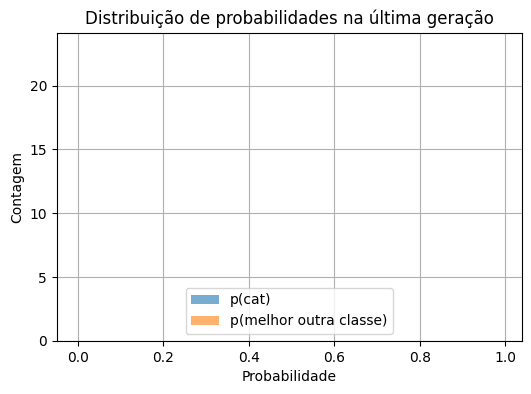

In [34]:

fig, ax = plt.subplots()
ax.hist(df_last["p_orig"], bins=30, alpha=0.6, label=f"p({orig_class_name})")
ax.hist(df_last["p_other_max"], bins=30, alpha=0.6, label="p(melhor outra classe)")
ax.set_xlabel("Probabilidade")
ax.set_ylabel("Contagem")
ax.set_title(f"Distribuição de probabilidades na última geração")
ax.legend()
plt.show()


In [35]:

frac_changed_last = df_last["changed_class"].mean()
print(f"Fração de indivíduos com mudança de classe na geração {last_gen}: {frac_changed_last:.3f}")


Fração de indivíduos com mudança de classe na geração 350: 1.000


## 6. Contraexemplos mínimos: pequenas distâncias que mudam a classe

In [36]:

df_ce = df[df["changed_class"] == 1].copy()
print("Total de contraexemplos encontrados:", len(df_ce))

df_ce_sorted = df_ce.sort_values("dist_norm")
df_ce_sorted.head(10)


Total de contraexemplos encontrados: 84265


,generation,index,fitness,margin_logit,dist_norm,dist_raw,p_orig,p_other_max,pred_class,changed_class
4037,17,37,3.091574,3.200993,0.218838,28.011215,0.038626,0.948527,5,1
4292,18,42,2.977671,3.088555,0.221767,28.386187,0.043006,0.943779,5,1
4526,19,26,2.607739,2.724041,0.232604,29.773338,0.060681,0.924880,5,1
3607,15,107,-0.021973,0.096833,0.237612,30.414396,0.463743,0.510894,5,1
3512,15,12,0.674638,0.795608,0.241940,30.968294,0.303173,0.671767,5,1
3442,14,192,0.727945,0.848915,0.241940,30.968294,0.292252,0.683025,5,1
4204,17,204,0.623966,0.745222,0.242512,31.041477,0.313863,0.661281,5,1
3758,16,8,0.435052,0.556308,0.242512,31.041500,0.355006,0.619209,5,1
3689,15,189,0.174627,0.296961,0.244668,31.317554,0.414877,0.558326,5,1
3104,13,104,0.445839,0.569573,0.247468,31.675892,0.352225,0.622563,5,1


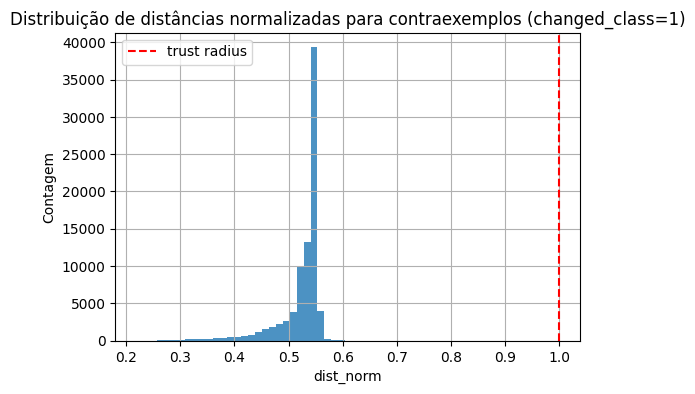

In [37]:

if len(df_ce) > 0:
    fig, ax = plt.subplots()
    ax.hist(df_ce["dist_norm"], bins=30, alpha=0.8)
    ax.axvline(trust_radius, color="red", linestyle="--", label="trust radius")
    ax.set_xlabel("dist_norm")
    ax.set_ylabel("Contagem")
    ax.set_title("Distribuição de distâncias normalizadas para contraexemplos (changed_class=1)")
    ax.legend()
    plt.show()
else:
    print("Nenhum contraexemplo (changed_class=1) foi encontrado.")


## 7. Direção latente do melhor contraexemplo (best_delta_z)

In [38]:

delta_flat = best_delta_z.flatten()
abs_delta = np.abs(delta_flat)

k = 20
topk_idx = np.argsort(-abs_delta)[:k]
topk_vals = delta_flat[topk_idx]

topk_df = pd.DataFrame({
    "latent_dim": topk_idx,
    "delta_z": topk_vals,
    "abs_delta_z": np.abs(topk_vals)
}).sort_values("abs_delta_z", ascending=False)

topk_df


,latent_dim,delta_z,abs_delta_z
0,1339,-5.028782,5.028782
1,2491,3.870526,3.870526
2,2287,-3.856159,3.856159
3,2858,3.644523,3.644523
4,3732,3.617506,3.617506
5,260,-3.604974,3.604974
6,3962,3.591583,3.591583
7,404,-3.578944,3.578944
8,3978,-3.558399,3.558399
9,2750,3.511026,3.511026


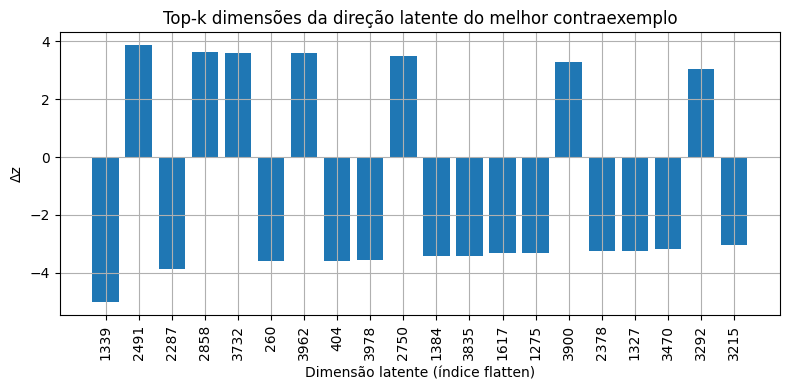

In [39]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(k), topk_df["delta_z"])
ax.set_xticks(range(k))
ax.set_xticklabels(topk_df["latent_dim"], rotation=90)
ax.set_xlabel("Dimensão latente (índice flatten)")
ax.set_ylabel("Δz")
ax.set_title("Top-k dimensões da direção latente do melhor contraexemplo")
plt.tight_layout()
plt.show()


## 8. Visualização de contraexemplos (opcional)

In [40]:

import torch

try:
    pop_final = torch.load(final_pop_path, map_location="cpu")  # lista de tensores [4,8,8]
    has_pop = True
    print("População final carregada com sucesso.")
except Exception as e:
    pop_final = None
    has_pop = False
    print("Não foi possível carregar final_population.pt:", e)


População final carregada com sucesso.


In [41]:

if has_pop:
    try:
        from diffusers import AutoencoderKL
        from torchvision import transforms as T
    except ImportError:
        print("diffusers/torchvision não instalados neste ambiente; pule a visualização.")
        has_pop = False


/scratch/samiramalaquias/venv_samis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [42]:

if has_pop:
    vae_model_name = config.get("VAE_MODEL", "stabilityai/sd-vae-ft-ema")
    DEVICE_VIS = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    vae_vis = AutoencoderKL.from_pretrained(vae_model_name).to(DEVICE_VIS)
    vae_vis.eval()

    to_pil = T.ToPILImage()

    def latent_batch_to_pil_vis(batch_z: torch.Tensor):
        with torch.no_grad():
            recon = vae_vis.decode(batch_z.to(DEVICE_VIS)).sample  # [B,3,32,32]
        recon = (recon.clamp(-1, 1) + 1.0) / 2.0
        recon_cpu = recon.cpu()
        pil_list = []
        for i in range(recon_cpu.shape[0]):
            img_rgb = recon_cpu[i]
            pil_32 = to_pil(img_rgb)
            pil = pil_32.resize((224, 224))
            pil_list.append(pil)
        return pil_list


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


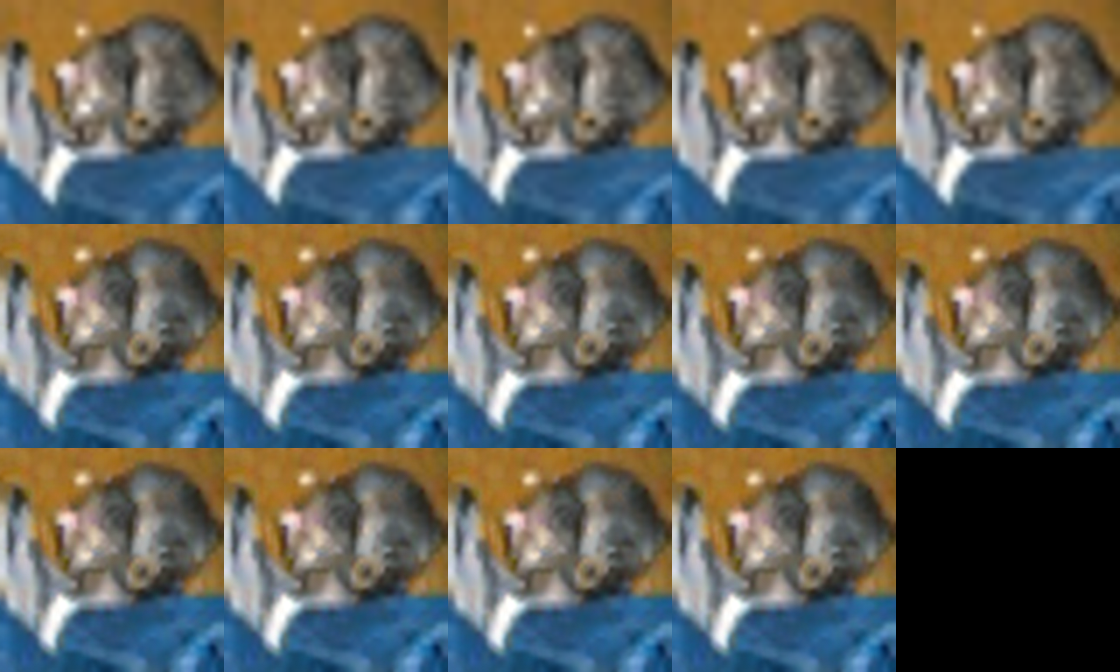

In [43]:

if has_pop:
    try:
        x0_path = config.get("INPUT_IMAGE_PATH", None)
        x0_pil = Image.open(x0_path).convert("RGB") if x0_path else None
    except Exception:
        x0_pil = None

    N_TOP = 9
    df_last_ce = df_last[df_last["changed_class"] == 1].copy()
    df_last_ce = df_last_ce.sort_values("dist_norm")
    df_top = df_last_ce.head(N_TOP)

    if len(df_top) == 0:
        print("Nenhum contraexemplo na última geração para visualizar.")
    else:
        n = len(df_top)
        n_cols = min(5, n)
        n_rows = int(np.ceil(n / n_cols))

        W, H = 224, 224
        extra_rows = 1 if x0_pil is not None else 0
        grid = Image.new("RGB", (n_cols * W, (n_rows + extra_rows) * H))

        if x0_pil is not None:
            x0_resized = x0_pil.resize((W, H))
            for c in range(n_cols):
                grid.paste(x0_resized, (c * W, 0))

        idx_list = list(df_top["index"].astype(int))
        batch_z = torch.stack([pop_final[i] for i in idx_list], dim=0)
        pil_imgs = latent_batch_to_pil_vis(batch_z)

        for j, pil in enumerate(pil_imgs):
            r = j // n_cols
            c = j % n_cols
            row_off = extra_rows
            grid.paste(pil, (c * W, (r + row_off) * H))

        display(grid)
else:
    print("Pule esta célula se não tiver a população final salva / diffusers instalado.")
